# SWAN-SF Data Exploration

Exploring the cleaned/preprocessed SWAN-SF dataset used for solar flare forecasting.

Each sample is a **multivariate time series**: 60 timesteps x 24 magnetic-field-derived
attributes (SHARP parameters), with a **binary label** (`1` = flare event, `0` = no flare).

- **Train**: 5 partitions, class-balanced via RUS-Tomek-TimeGAN resampling.
- **Test**: 5 partitions, left in natural (heavily imbalanced) proportions.

This notebook loads all partitions and looks at class balance, feature distributions,
temporal trends per class, and inter-attribute correlation.

## Setup

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import load_partitions, ATTRIBUTES

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Load all partitions

`load_partitions` returns a list of arrays (one per partition), each shaped
`(n_samples, 60, 24)` for features and `(n_samples,)` for labels.

In [2]:
X_train_parts, y_train_parts = load_partitions(split="train", num_partitions=5)
X_test_parts, y_test_parts = load_partitions(split="test", num_partitions=5)

X_train = np.concatenate(X_train_parts, axis=0)
y_train = np.concatenate(y_train_parts, axis=0)
X_test = np.concatenate(X_test_parts, axis=0)
y_test = np.concatenate(y_test_parts, axis=0)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)


X_train: (97764, 60, 24)  y_train: (97764,)
X_test:  (331185, 60, 24)  y_test:  (331185,)


## Partition sizes & class balance

Train partitions are resampled to be near-balanced; test partitions reflect the true, rare-event class ratio.

In [3]:
summary_rows = []
for i, (x, y) in enumerate(zip(X_train_parts, y_train_parts), start=1):
    n_pos = int((y == 1).sum())
    summary_rows.append(["train", i, len(y), n_pos, len(y) - n_pos, n_pos / len(y)])
for i, (x, y) in enumerate(zip(X_test_parts, y_test_parts), start=1):
    n_pos = int((y == 1).sum())
    summary_rows.append(["test", i, len(y), n_pos, len(y) - n_pos, n_pos / len(y)])

summary = pd.DataFrame(summary_rows, columns=["split", "partition", "n_samples", "n_flare", "n_no_flare", "flare_ratio"])
summary


,split,partition,n_samples,n_flare,n_no_flare,flare_ratio
0,train,1,18773,8778,9995,0.467586
1,train,2,19807,9807,10000,0.495128
2,train,3,19965,9968,9997,0.499274
3,train,4,19320,9320,10000,0.482402
4,train,5,19899,9900,9999,0.497512
5,test,1,73492,1254,72238,0.017063
6,test,2,88557,1401,87156,0.015820
7,test,3,42510,1424,41086,0.033498
8,test,4,51261,1165,50096,0.022727
9,test,5,75365,990,74375,0.013136


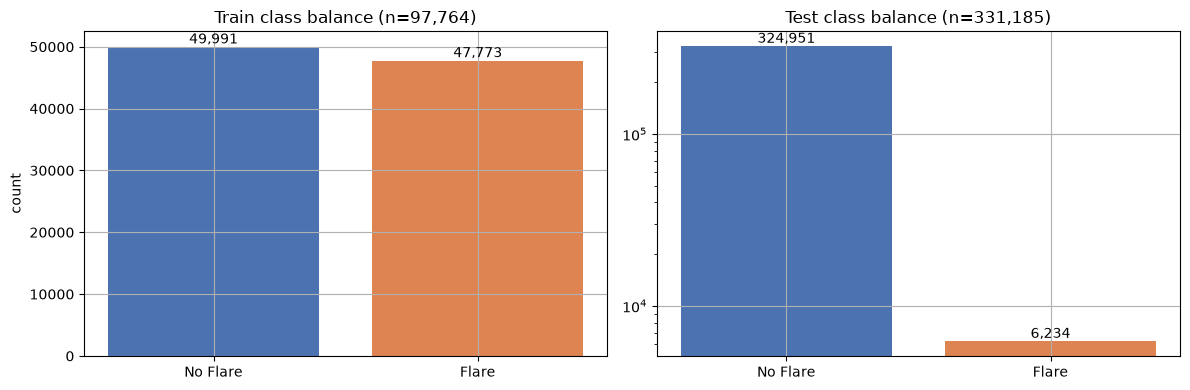

Train flare ratio: 48.9%
Test flare ratio:  1.9%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

axes[0].bar(["No Flare", "Flare"], train_counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title(f"Train class balance (n={len(y_train):,})")
axes[0].set_ylabel("count")
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(["No Flare", "Flare"], test_counts.values, color=["#4C72B0", "#DD8452"])
axes[1].set_title(f"Test class balance (n={len(y_test):,})")
axes[1].set_yscale("log")
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"Train flare ratio: {train_counts[1] / train_counts.sum():.1%}")
print(f"Test flare ratio:  {test_counts[1] / test_counts.sum():.1%}")


**Takeaway:** the train set is artificially balanced (~48% flare), but the test set is
dominated by the negative class (flare ratio well under 5%). Any model evaluated on test
needs metrics robust to imbalance (recall, precision, F1, TSS/HSS) rather than raw accuracy.

## Feature value ranges

All attributes were normalized (LSBZM-Norm), so we'd expect roughly bounded ranges.

In [5]:
# Flatten (samples, timesteps, features) -> (samples*timesteps, features) for a global view
flat_train = X_train.reshape(-1, X_train.shape[-1])

feat_stats = pd.DataFrame(flat_train, columns=ATTRIBUTES).describe().T[["mean", "std", "min", "max"]]
feat_stats.sort_values("std", ascending=False)


,mean,std,min,max
MEANJZH,0.418862,0.285767,0.0,1.0
USFLUX,0.667396,0.282523,0.0,1.0
TOTBSQ,0.669214,0.281912,0.0,1.0
TOTUSJZ,0.665785,0.274526,0.0,1.0
TOTUSJH,0.520602,0.264823,0.0,1.0
ABSNJZH,0.629822,0.186962,0.0,1.0
SHRGT45,0.222821,0.183663,0.0,1.0
EPSX,0.501117,0.176135,0.0,1.0
TOTFY,0.690568,0.174807,0.0,1.0
R_VALUE,0.688536,0.173672,0.0,1.0


## Temporal patterns: mean attribute trajectory by class

For a handful of physically meaningful SHARP parameters, plot the mean value across the
60-timestep window, split by class. A separating trend near the end of the window is what
a forecasting model would be picking up on.

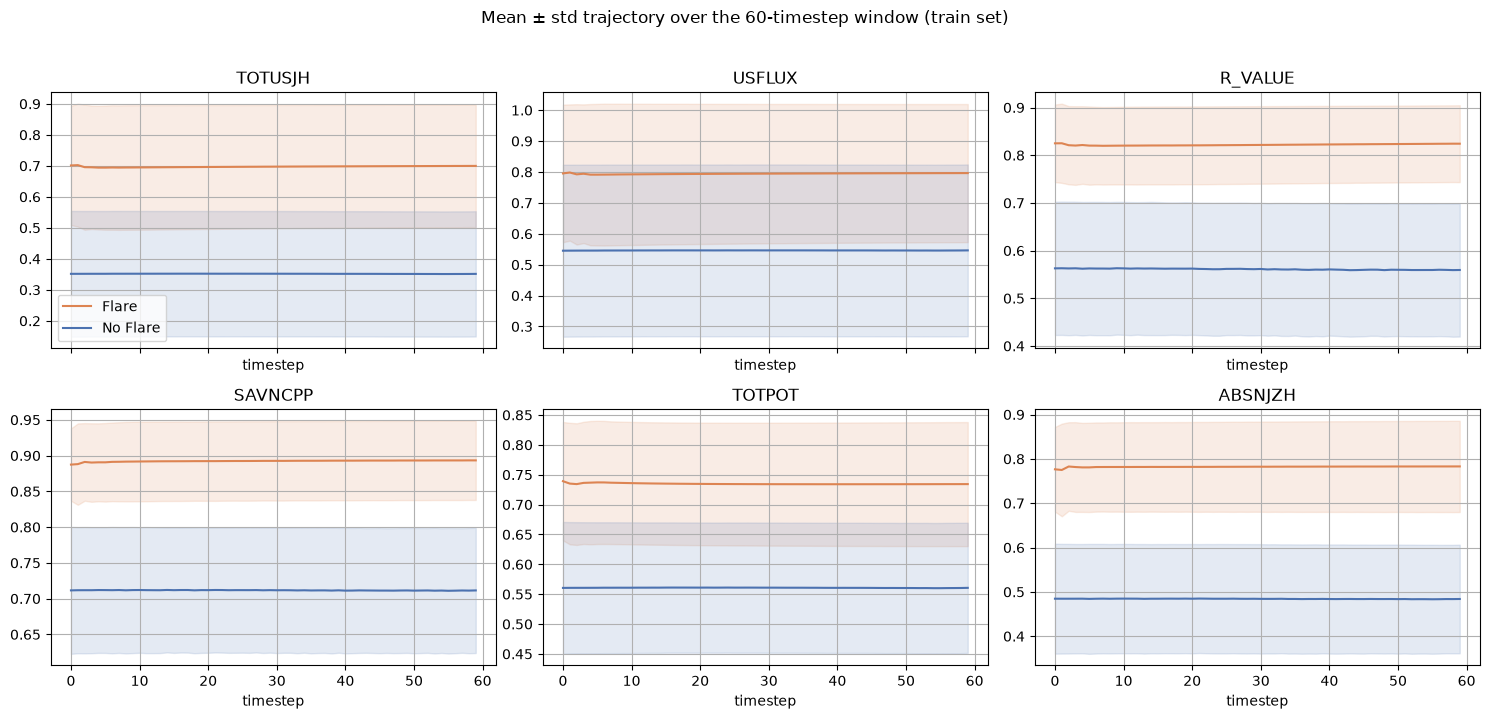

In [6]:
key_attrs = ["TOTUSJH", "USFLUX", "R_VALUE", "SAVNCPP", "TOTPOT", "ABSNJZH"]
attr_idx = {a: ATTRIBUTES.index(a) for a in key_attrs}

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.ravel()

for ax, attr in zip(axes, key_attrs):
    idx = attr_idx[attr]
    flare_mean = X_train[y_train == 1, :, idx].mean(axis=0)
    noflare_mean = X_train[y_train == 0, :, idx].mean(axis=0)
    flare_std = X_train[y_train == 1, :, idx].std(axis=0)
    noflare_std = X_train[y_train == 0, :, idx].std(axis=0)

    t = np.arange(X_train.shape[1])
    ax.plot(t, flare_mean, label="Flare", color="#DD8452")
    ax.fill_between(t, flare_mean - flare_std, flare_mean + flare_std, alpha=0.15, color="#DD8452")
    ax.plot(t, noflare_mean, label="No Flare", color="#4C72B0")
    ax.fill_between(t, noflare_mean - noflare_std, noflare_mean + noflare_std, alpha=0.15, color="#4C72B0")

    ax.set_title(attr)
    ax.set_xlabel("timestep")

axes[0].legend()
fig.suptitle("Mean ± std trajectory over the 60-timestep window (train set)", y=1.02)
plt.tight_layout()
plt.show()


## Distribution of final-timestep values by class

The last timestep is closest to the forecast point, so its distribution is often the most predictive.

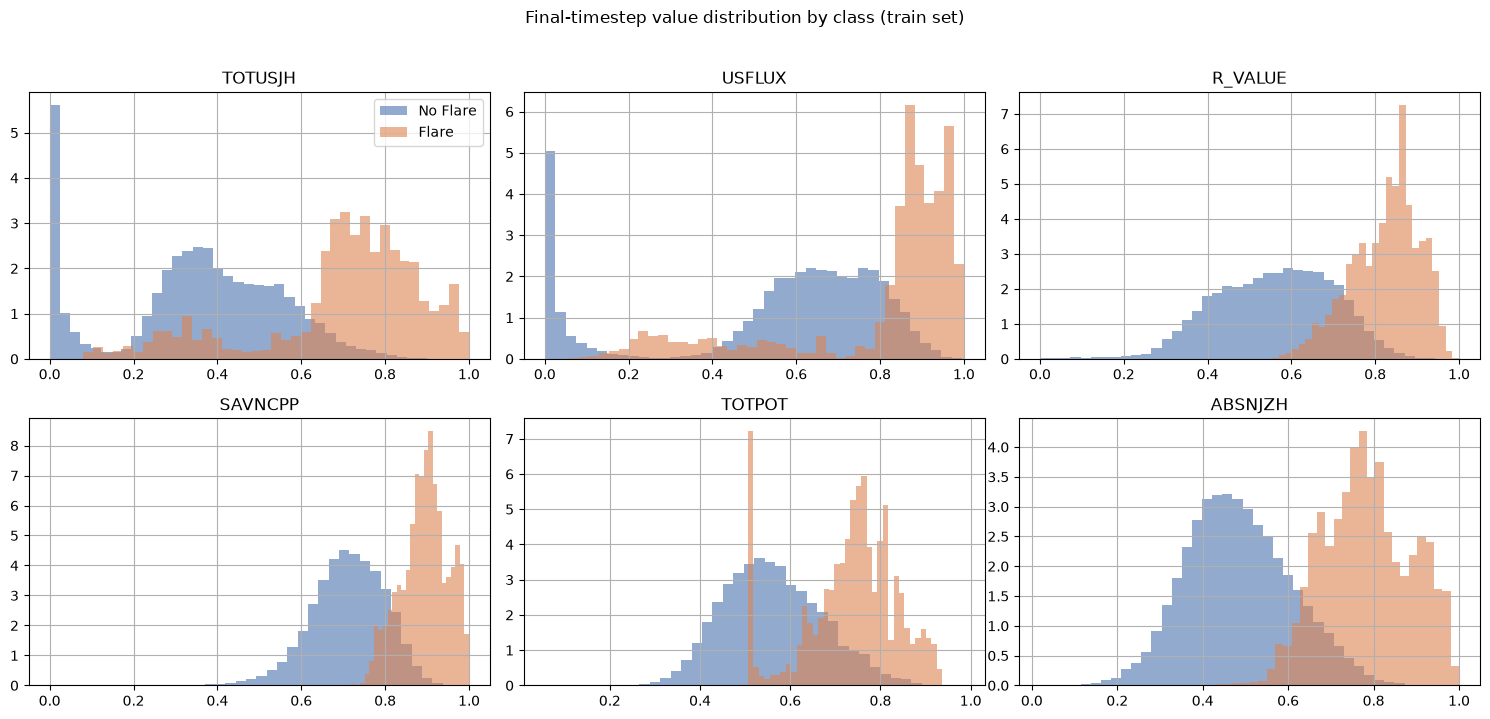

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()

last_step = X_train.shape[1] - 1

for ax, attr in zip(axes, key_attrs):
    idx = attr_idx[attr]
    vals_flare = X_train[y_train == 1, last_step, idx]
    vals_noflare = X_train[y_train == 0, last_step, idx]

    ax.hist(vals_noflare, bins=40, alpha=0.6, label="No Flare", color="#4C72B0", density=True)
    ax.hist(vals_flare, bins=40, alpha=0.6, label="Flare", color="#DD8452", density=True)
    ax.set_title(attr)

axes[0].legend()
fig.suptitle("Final-timestep value distribution by class (train set)", y=1.02)
plt.tight_layout()
plt.show()


## Attribute correlation

Using the final timestep of each sample, check for redundant/highly correlated SHARP parameters.

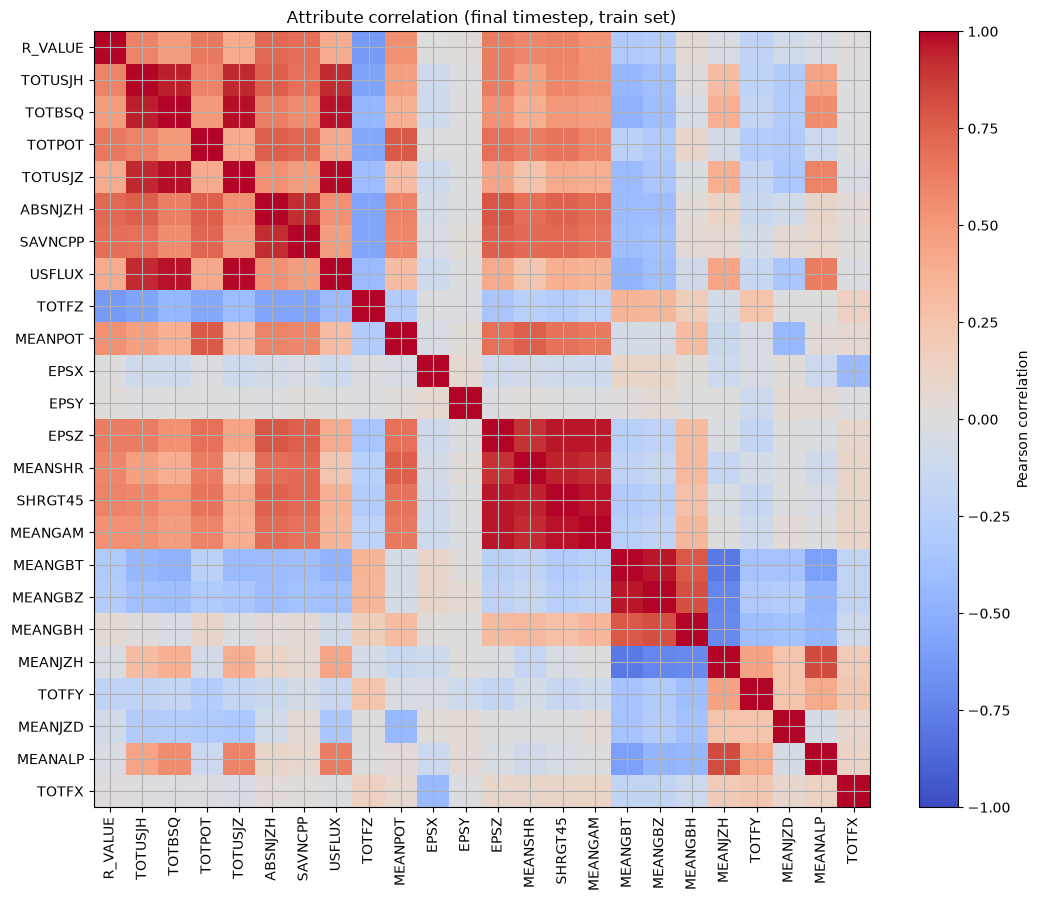

In [8]:
final_step_df = pd.DataFrame(X_train[:, -1, :], columns=ATTRIBUTES)
corr = final_step_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(ATTRIBUTES)))
ax.set_xticklabels(ATTRIBUTES, rotation=90)
ax.set_yticks(range(len(ATTRIBUTES)))
ax.set_yticklabels(ATTRIBUTES)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Attribute correlation (final timestep, train set)")
plt.tight_layout()
plt.show()


In [9]:
# Most correlated attribute pairs (excluding self-correlation)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "attr_1", "level_1": "attr_2"})
)
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(15)


,attr_1,attr_2,corr,abs_corr
103,TOTUSJZ,USFLUX,0.992064,0.992064
52,TOTBSQ,TOTUSJZ,0.977904,0.977904
55,TOTBSQ,USFLUX,0.974346,0.974346
351,SHRGT45,MEANGAM,0.973568,0.973568
303,EPSZ,MEANGAM,0.964866,0.964866
302,EPSZ,SHRGT45,0.961603,0.961603
401,MEANGBT,MEANGBZ,0.961105,0.961105
26,TOTUSJH,TOTBSQ,0.949473,0.949473
326,MEANSHR,SHRGT45,0.939420,0.939420
28,TOTUSJH,TOTUSJZ,0.933649,0.933649


## Summary of observations

- **Class imbalance**: train is resampled to near 50/50, but test reflects the true rarity
  of flares (roughly 1-3% positive per partition) — evaluation must account for this.
- **Temporal trends**: several SHARP parameters (`TOTUSJH`, `USFLUX`, `SAVNCPP`, `ABSNJZH`)
  show visibly higher mean magnitude and/or divergence for the flare class as the window
  progresses, suggesting the time dimension carries predictive signal, not just the final
  snapshot.
- **Distribution separation**: at the final timestep, flare vs. no-flare distributions
  overlap substantially for most attributes but are visibly shifted for magnetic complexity
  proxies (`TOTUSJH`, `SAVNCPP`), which are good candidates for a strong baseline model.
- **Redundancy**: several attribute pairs are highly correlated, which is expected since many
  SHARP parameters are variants of current/magnetic-flux complexity — worth considering
  dimensionality reduction or regularization for linear models.

Next steps: build a baseline classifier (e.g. logistic regression or gradient boosting on
flattened/aggregated features) evaluated with TSS/HSS-style metrics, then compare against a
sequence model (LSTM/1D-CNN) that can exploit the temporal trends observed above.